In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.facecolor'] = '#0d1117'
plt.rcParams['figure.facecolor'] = '#0d1117'
plt.rcParams['axes.edgecolor'] = '#30363d'
plt.rcParams['axes.labelcolor'] = '#e6edf3'
plt.rcParams['xtick.color'] = '#8b949e'
plt.rcParams['ytick.color'] = '#8b949e'
plt.rcParams['text.color'] = '#e6edf3'
plt.rcParams['grid.color'] = '#21262d'
plt.rcParams['axes.titlecolor'] = '#e6edf3'

print("All libraries imported successfully!")

All libraries imported successfully!


In [5]:
# Load dataset
columns = ['engine_id', 'cycle'] + \
          [f'op_setting_{i}' for i in range(1, 4)] + \
          [f'sensor_{i}' for i in range(1, 22)]

df = pd.read_csv('data/train_FD001.txt', sep=r'\s+', header=None, names=columns)

# Calculate RUL
max_cycles = df.groupby('engine_id')['cycle'].max().reset_index()
max_cycles.columns = ['engine_id', 'max_cycle']
df = df.merge(max_cycles, on='engine_id')
df['RUL'] = df['max_cycle'] - df['cycle']
df.drop('max_cycle', axis=1, inplace=True)

print("Dataset loaded successfully!")
print(f"\nDataset Shape: {df.shape}")
print(f"Total Engines: {df['engine_id'].nunique()}")
print(f"Total Cycles: {df['cycle'].sum():,}")
print(f"Avg cycles per engine: {df.groupby('engine_id')['cycle'].max().mean():.1f}")
print(f"\nFirst 5 rows:")
df.head()

Dataset loaded successfully!

Dataset Shape: (20631, 27)
Total Engines: 100
Total Cycles: 2,244,815
Avg cycles per engine: 206.3

First 5 rows:


,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


In [6]:
print("Dataset Info:")
print(f"   Rows: {df.shape[0]:,}")
print(f"   Columns: {df.shape[1]}")
print(f"\nMissing Values: {df.isnull().sum().sum()}")
print(f"Duplicate Rows: {df.duplicated().sum()}")
print(f"\n RUL Statistics:")
print(df['RUL'].describe().round(2))

Dataset Info:
   Rows: 20,631
   Columns: 27

Missing Values: 0
Duplicate Rows: 0

 RUL Statistics:
count    20631.00
mean       107.81
std         68.88
min          0.00
25%         51.00
50%        103.00
75%        155.00
max        361.00
Name: RUL, dtype: float64


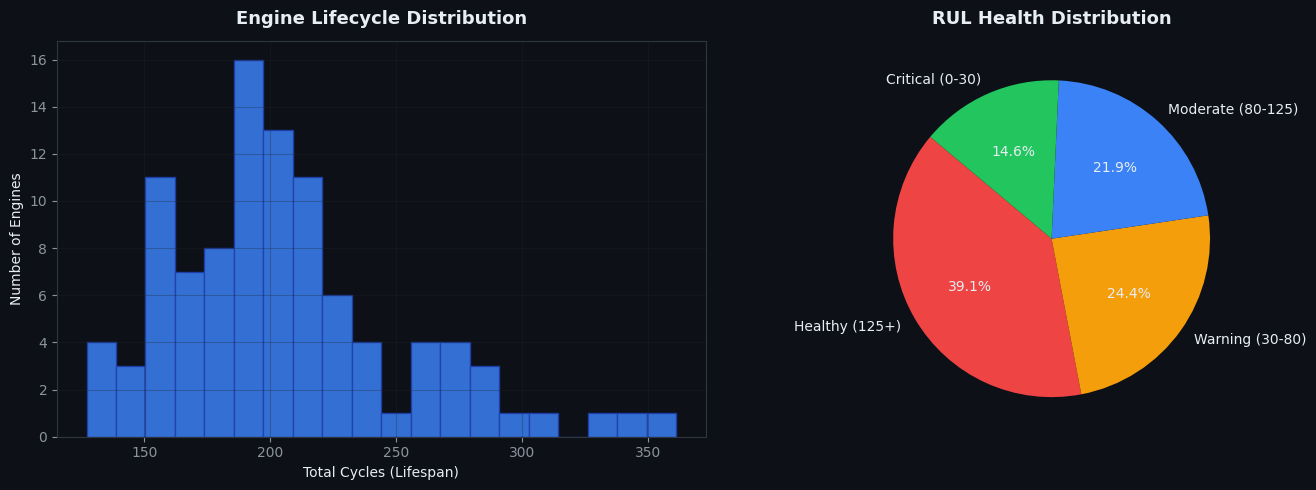

✅ Engine lifecycle analysis complete!


In [7]:
max_rul = df.groupby('engine_id')['RUL'].max()

plt.figure(figsize=(14, 5))

# Plot 1
plt.subplot(1, 2, 1)
plt.hist(max_rul, bins=20, color='#3b82f6', edgecolor='#1e40af', alpha=0.85)
plt.title('Engine Lifecycle Distribution', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Total Cycles (Lifespan)')
plt.ylabel('Number of Engines')
plt.grid(True, alpha=0.3)

# Plot 2
plt.subplot(1, 2, 2)
rul_bins = pd.cut(df['RUL'], bins=[0, 30, 80, 125, 400],
                  labels=['Critical (0-30)', 'Warning (30-80)', 'Moderate (80-125)', 'Healthy (125+)'])
rul_counts = rul_bins.value_counts()
colors = ['#ef4444', '#f59e0b', '#3b82f6', '#22c55e']
plt.pie(rul_counts, labels=rul_counts.index, colors=colors,
        autopct='%1.1f%%', startangle=140,
        textprops={'color': '#e6edf3', 'fontsize': 10})
plt.title('RUL Health Distribution', fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
plt.show()
print("✅ Engine lifecycle analysis complete!")

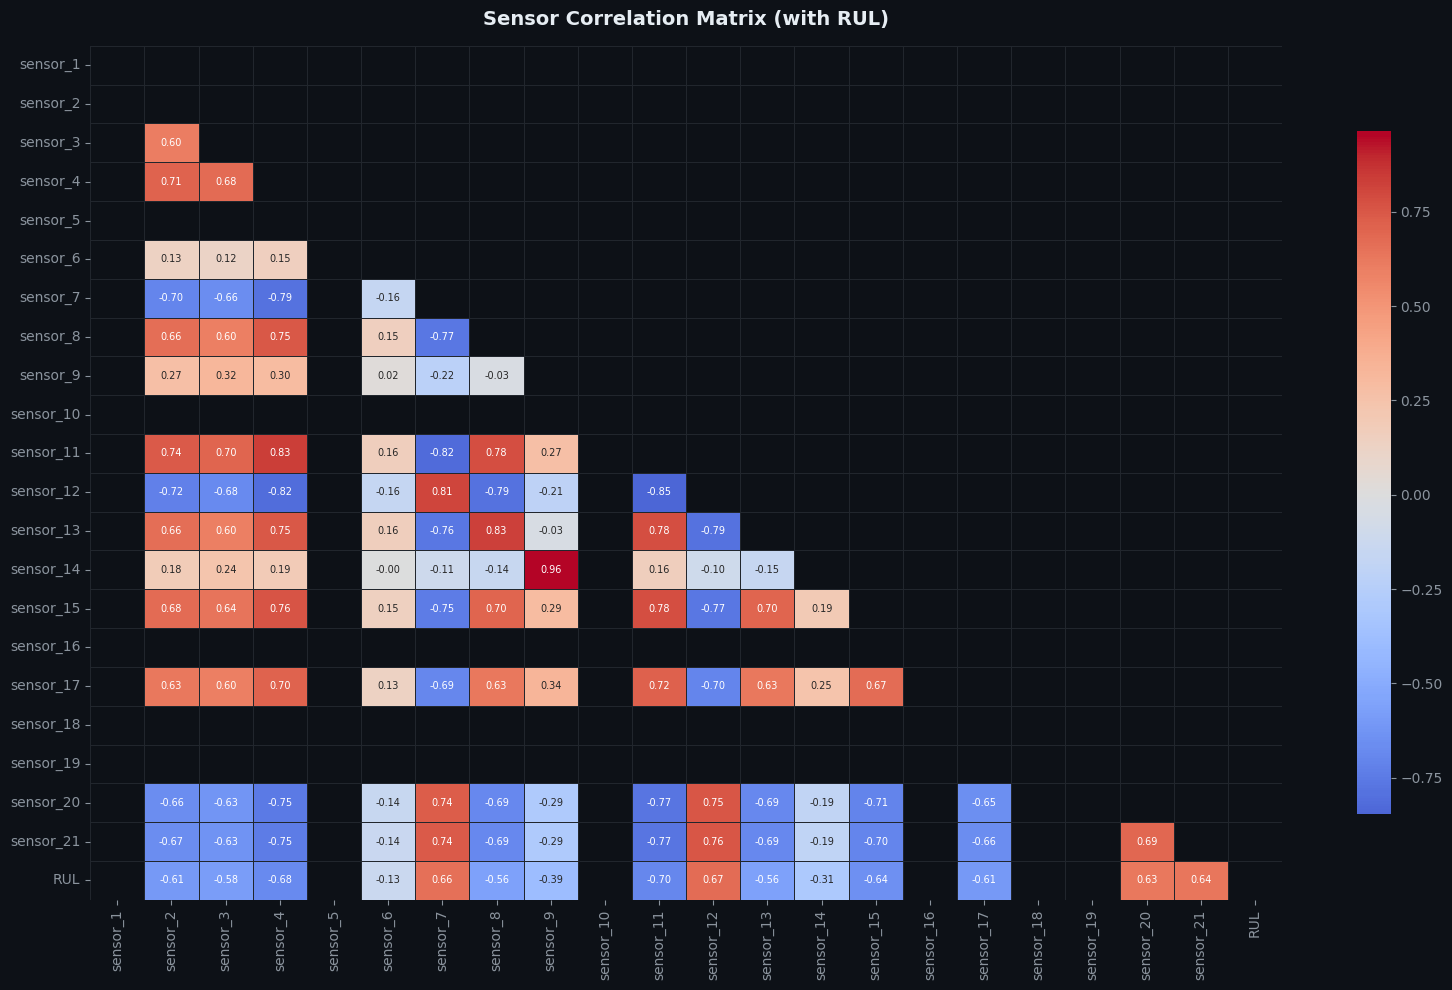

✅ Correlation heatmap complete!


In [8]:
sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
corr = df[sensor_cols + ['RUL']].corr()

plt.figure(figsize=(16, 10))
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5, linecolor='#21262d',
    annot_kws={'size': 7},
    cbar_kws={'shrink': 0.8}
)
plt.title('Sensor Correlation Matrix (with RUL)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()
print("✅ Correlation heatmap complete!")

Top 6 sensors most correlated with RUL:
   1. sensor_11 — correlation: 0.696
   2. sensor_4 — correlation: 0.679
   3. sensor_12 — correlation: 0.672
   4. sensor_7 — correlation: 0.657
   5. sensor_15 — correlation: 0.643
   6. sensor_21 — correlation: 0.636


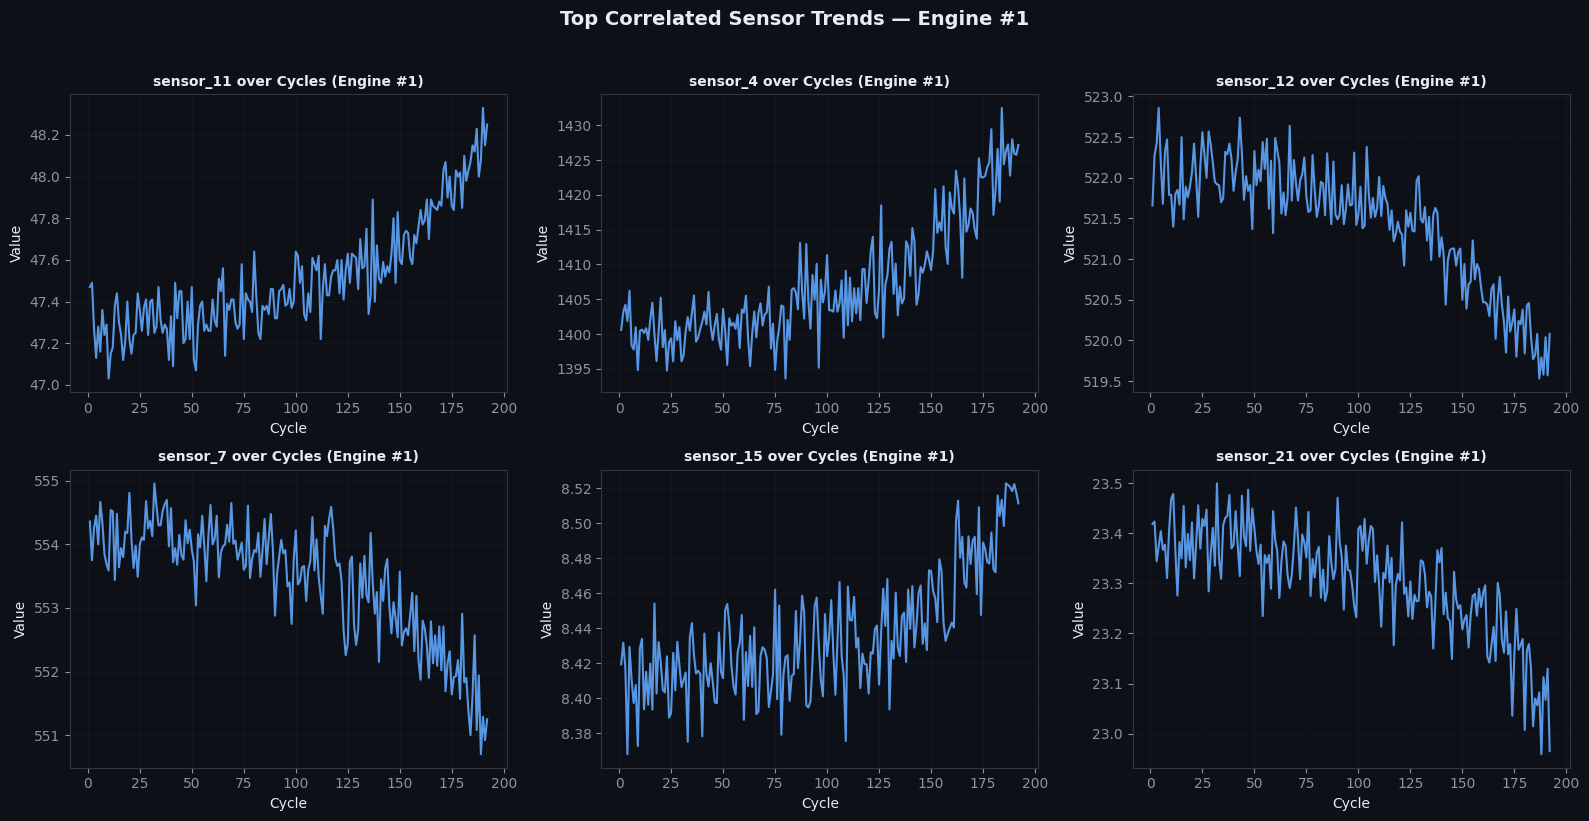

Sensor trend analysis complete!


In [9]:
# Find top 6 sensors most correlated with RUL
rul_corr = df[sensor_cols].corrwith(df['RUL']).abs().sort_values(ascending=False)
top_sensors = rul_corr.head(6).index.tolist()

print("Top 6 sensors most correlated with RUL:")
for i, s in enumerate(top_sensors):
    print(f"   {i+1}. {s} — correlation: {rul_corr[s]:.3f}")

# Sample one engine for trend plot
sample_engine = df[df['engine_id'] == 1]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, sensor in enumerate(top_sensors):
    axes[i].plot(sample_engine['cycle'], sample_engine[sensor],
                 color='#60a5fa', linewidth=1.5, alpha=0.9)
    axes[i].set_title(f'{sensor} over Cycles (Engine #1)',
                      fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Cycle')
    axes[i].set_ylabel('Value')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Top Correlated Sensor Trends — Engine #1',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("Sensor trend analysis complete!")

In [13]:
FEATURE_COLS = [f'sensor_{i}' for i in range(1, 22)] + \
               [f'op_setting_{i}' for i in range(1, 4)]

# Cap RUL at 125 (standard practice for CMAPSS)
df['RUL_capped'] = df['RUL'].clip(upper=125)

X = df[FEATURE_COLS]
y = df['RUL_capped']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Feature engineering complete!")
print(f"\nTraining samples : {X_train.shape[0]:,}")
print(f"Testing samples  : {X_test.shape[0]:,}")
print(f"Features used    : {len(FEATURE_COLS)}")
print(f"RUL range (capped): 0 – {y.max()}")

Feature engineering complete!

Training samples : 16,504
Testing samples  : 4,127
Features used    : 24
RUL range (capped): 0 – 125


In [14]:
models = {
    'Linear Regression'        : LinearRegression(),
    'Random Forest'            : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting'        : GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost'                  : xgb.XGBRegressor(n_estimators=100, random_state=42,
                                                    verbosity=0, n_jobs=-1),
}

results = {}

print("🔧 Training models...\n")
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'predictions': y_pred}

    print(f"{name}")
    print(f"   MAE  : {mae:.2f}")
    print(f"   RMSE : {rmse:.2f}")
    print(f"   R²   : {r2:.4f}")
    print()

print("All models trained!")

🔧 Training models...

Linear Regression
   MAE  : 17.62
   RMSE : 21.68
   R²   : 0.7229

Random Forest
   MAE  : 13.61
   RMSE : 18.83
   R²   : 0.7910

Gradient Boosting
   MAE  : 13.55
   RMSE : 18.77
   R²   : 0.7923

XGBoost
   MAE  : 13.91
   RMSE : 19.61
   R²   : 0.7733

All models trained!


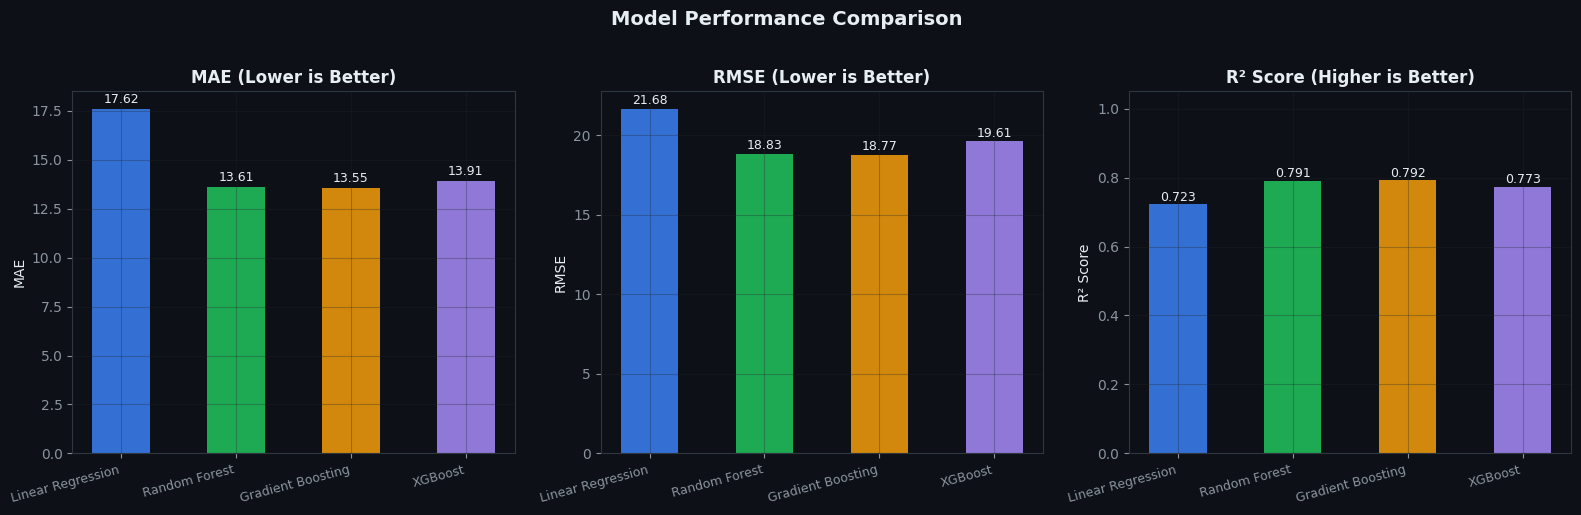

Model comparison complete!


In [16]:
model_names = list(results.keys())
maes  = [results[m]['MAE']  for m in model_names]
rmses = [results[m]['RMSE'] for m in model_names]
r2s   = [results[m]['R2']   for m in model_names]

x = np.arange(len(model_names))
width = 0.28

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# MAE
axes[0].bar(x, maes, width=0.5, color=['#3b82f6','#22c55e','#f59e0b','#a78bfa'], alpha=0.85)
axes[0].set_title('MAE (Lower is Better)', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=15, ha='right', fontsize=9)
axes[0].set_ylabel('MAE')
axes[0].grid(True, alpha=0.3)
for i, v in enumerate(maes):
    axes[0].text(i, v + 0.3, f'{v:.2f}', ha='center', fontsize=9, color='#e6edf3')

# RMSE
axes[1].bar(x, rmses, width=0.5, color=['#3b82f6','#22c55e','#f59e0b','#a78bfa'], alpha=0.85)
axes[1].set_title('RMSE (Lower is Better)', fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, rotation=15, ha='right', fontsize=9)
axes[1].set_ylabel('RMSE')
axes[1].grid(True, alpha=0.3)
for i, v in enumerate(rmses):
    axes[1].text(i, v + 0.3, f'{v:.2f}', ha='center', fontsize=9, color='#e6edf3')

# R²
axes[2].bar(x, r2s, width=0.5, color=['#3b82f6','#22c55e','#f59e0b','#a78bfa'], alpha=0.85)
axes[2].set_title('R² Score (Higher is Better)', fontweight='bold')
axes[2].set_xticks(x)
axes[2].set_xticklabels(model_names, rotation=15, ha='right', fontsize=9)
axes[2].set_ylabel('R² Score')
axes[2].set_ylim(0, 1.05)
axes[2].grid(True, alpha=0.3)
for i, v in enumerate(r2s):
    axes[2].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9, color='#e6edf3')

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("Model comparison complete!")

Using best model: Gradient Boosting


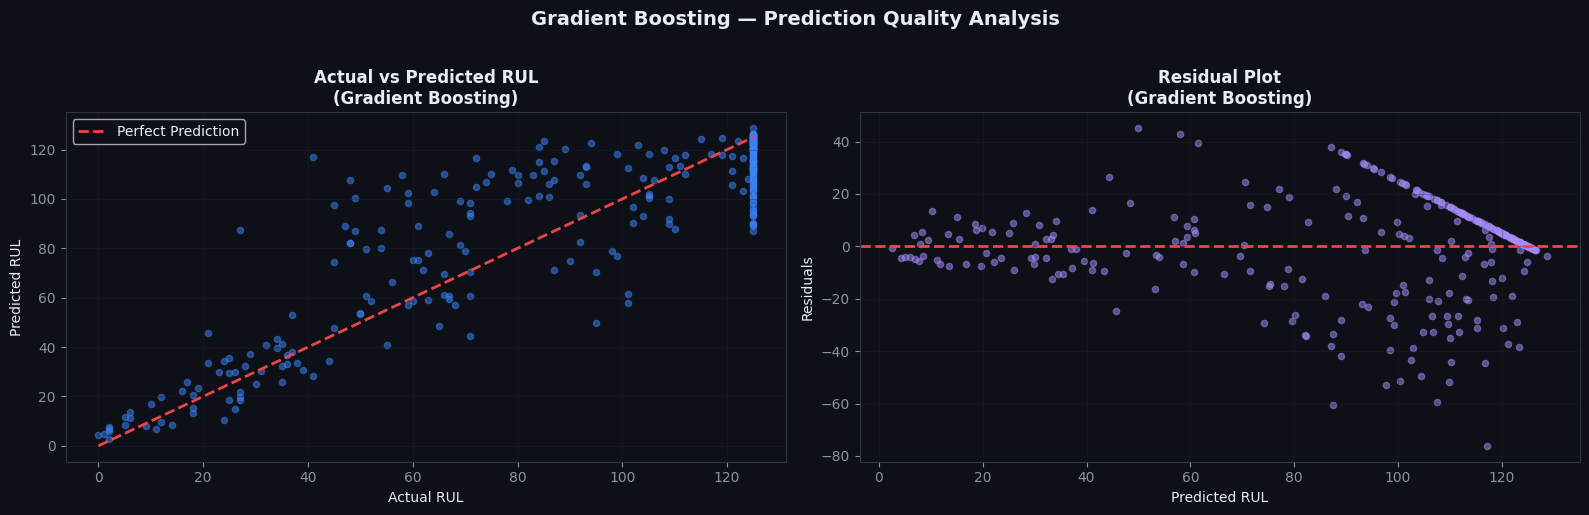

Prediction analysis complete!


In [34]:
# Use best model (Here it is Gradient Boosting- Analysis from above cell output)
best_model_name = max(results, key=lambda x: results[x]['R2'])
best_preds = results[best_model_name]['predictions']
print(f"Using best model: {best_model_name}")

# Sample 300 points for clarity
idx = np.random.choice(len(y_test), 300, replace=False)
y_sample      = np.array(y_test)[idx]
pred_sample   = best_preds[idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Scatter plot
axes[0].scatter(y_sample, pred_sample, alpha=0.5, color='#3b82f6', s=20)
axes[0].plot([0, 125], [0, 125], color='#ef4444', linewidth=2, linestyle='--', label='Perfect Prediction')
axes[0].set_xlabel('Actual RUL')
axes[0].set_ylabel('Predicted RUL')
axes[0].set_title('Actual vs Predicted RUL\n(Gradient Boosting)', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residual plot
residuals = y_sample - pred_sample
axes[1].scatter(pred_sample, residuals, alpha=0.5, color='#a78bfa', s=20)
axes[1].axhline(y=0, color='#ef4444', linewidth=2, linestyle='--')
axes[1].set_xlabel('Predicted RUL')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot\n(Gradient Boosting)', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Gradient Boosting — Prediction Quality Analysis',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("Prediction analysis complete!")

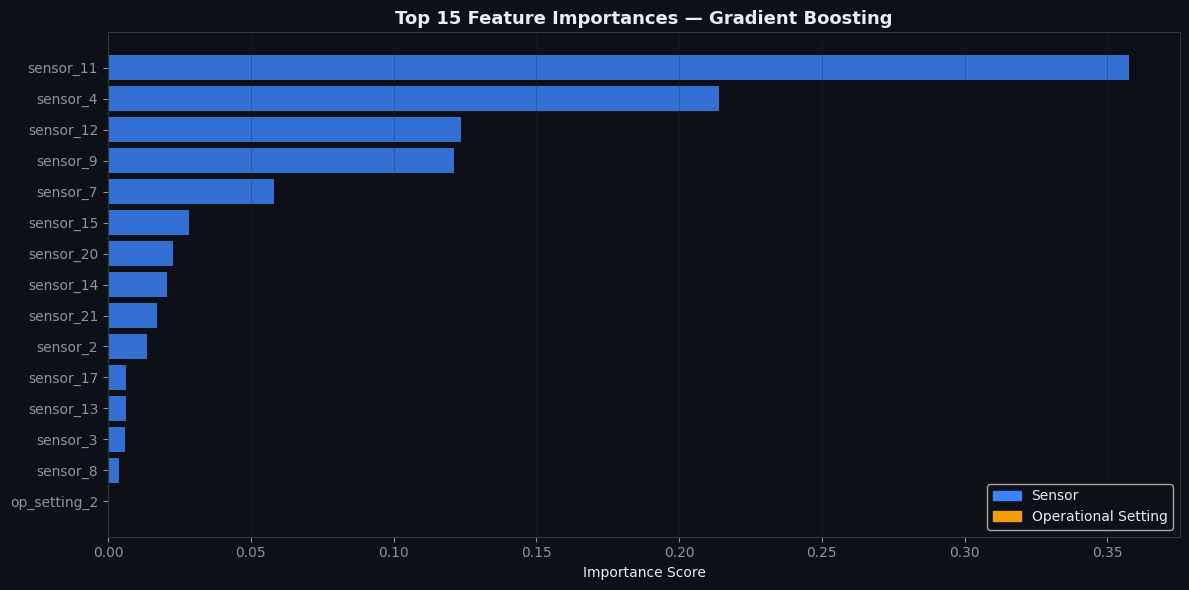

Feature importance analysis complete!

Top 5 most important features:
   sensor_11 — 0.3575
   sensor_4 — 0.2140
   sensor_12 — 0.1236
   sensor_9 — 0.1210
   sensor_7 — 0.0583


In [35]:
gb_model = models[best_model_name]
importances = gb_model.feature_importances_
feat_df = pd.DataFrame({
    'Feature'   : FEATURE_COLS,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(12, 6))
colors = ['#3b82f6' if 'sensor' in f else '#f59e0b' for f in feat_df['Feature']]
bars = plt.barh(feat_df['Feature'][::-1], feat_df['Importance'][::-1],
                color=colors[::-1], alpha=0.85)

blue_patch   = mpatches.Patch(color='#3b82f6', label='Sensor')
yellow_patch = mpatches.Patch(color='#f59e0b', label='Operational Setting')
plt.legend(handles=[blue_patch, yellow_patch], loc='lower right')

plt.xlabel('Importance Score')
plt.title('Top 15 Feature Importances — Gradient Boosting', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("Feature importance analysis complete!")
print(f"\nTop 5 most important features:")
for i, row in feat_df.head(5).iterrows():
    print(f"   {row['Feature']} — {row['Importance']:.4f}")

In [36]:
best_model = max(results, key=lambda x: results[x]['R2'])
best = results[best_model]

print("=" * 55)
print("       AEROSENSE — MODEL EVALUATION SUMMARY")
print("=" * 55)
print(f"\n{'Model':<25} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print("-" * 55)
for name, r in results.items():
    star = " * " if name == best_model else ""
    print(f"{name:<25} {r['MAE']:>8.2f} {r['RMSE']:>8.2f} {r['R2']:>8.4f}{star}")

print("=" * 55)
print(f"\nBest Model     : {best_model}")
print(f"   MAE           : {best['MAE']:.2f} cycles")
print(f"   RMSE          : {best['RMSE']:.2f} cycles")
print(f"   R² Score      : {best['R2']:.4f}")
print(f"\nDataset        : NASA CMAPSS FD001")
print(f"Total Samples  : {len(df):,}")
print(f"Features Used  : {len(FEATURE_COLS)}")
print(f"Engines        : {df['engine_id'].nunique()}")
print("\nAnalysis complete")

       AEROSENSE — MODEL EVALUATION SUMMARY

Model                          MAE     RMSE       R²
-------------------------------------------------------
Linear Regression            17.62    21.68   0.7229
Random Forest                13.61    18.83   0.7910
Gradient Boosting            13.55    18.77   0.7923 * 
XGBoost                      13.91    19.61   0.7733

Best Model     : Gradient Boosting
   MAE           : 13.55 cycles
   RMSE          : 18.77 cycles
   R² Score      : 0.7923

Dataset        : NASA CMAPSS FD001
Total Samples  : 20,631
Features Used  : 24
Engines        : 100

Analysis complete
